# TMDB Movie Data Analysis (PySpark)

This notebook explores the cleaned TMDb dataset, computes KPIs, and visualizes results, using PySpark instead of pandas for the underlying data processing. All fetching, cleaning, KPI, and chart logic lives in `src/` as importable, tested modules — this notebook focuses on running that logic and interpreting what it shows.

Results are displayed via `.toPandas()` for readable table rendering in Jupyter, since these are always small, already-filtered or aggregated results (top-N rankings, group summaries) – never the full raw dataset.

In [2]:
import sys
sys.path.append("../src")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder.appName("TMDBAnalysisNotebook").master("local[*]").getOrCreate()

from analysis.kpis import (
    add_financial_columns,
    add_franchise_status,
    rank_movies,
    search_movies,
    compare_franchise_vs_standalone,
    franchise_success,
    director_success,
)
from visualization.visualize import (
    plot_revenue_vs_budget,
    plot_roi_by_genre,
    plot_popularity_vs_rating,
    plot_yearly_trends,
    plot_franchise_vs_standalone,
)

df = spark.read.parquet("../data/processed/movies_clean.parquet")
df = add_financial_columns(df)
df = add_franchise_status(df)

2026-08-09 11:59:13,266 [INFO] analysis.kpis: Added profit_musd and roi columns


# Step 3: KPI Implementation & Analysis

## Identify the Best/Worst Performing Movies

Rather than repeating filter-sort-top-N logic for every ranking, we use the reusable `rank_movies()` function (see `src/analysis/kpis.py`).

### Highest Revenue

In [3]:
rank_movies(df, by="revenue_musd").toPandas()

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi,franchise_status
0,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,20th Century Fox|Dune Entertainment|Ingenious ...,...,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,68,James Cameron,1000,2686.706026,12.336312,Franchise
1,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Action|Adventure|Science Fiction,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,After the devastating events of Avengers: Infi...,|English|日本語,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,106,Anthony Russo|Joe Russo,613,2443.439100,7.863593,Franchise
2,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,None,en,200.0,2264.162353,20th Century Fox|Lightstorm Entertainment|Para...,...,101-year-old Rose DeWitt Bukater tells the sto...,Deutsch|English|Français|Italiano|Pусский|svenska,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,117,James Cameron,270,2064.162353,11.320812,Standalone
3,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Action|Adventure|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Bad Robot|Lucasfilm Ltd.,...,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,269,1823.223624,8.441729,Franchise
4,299536,Avengers: Infinity War,An entire universe. Once and for all.,2018-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,As the Avengers and their allies have continue...,|English,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,70,Anthony Russo|Joe Russo,736,1752.415039,6.841383,Franchise
5,135397,Jurassic World,The park is open.,2015-06-06,Action|Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Legendary Pictures|Univer...,...,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,53,Colin Trevorrow,420,1521.537444,11.143583,Franchise
6,420818,The Lion King,The king has returned.,2019-07-12,Adventure|Animation|Drama|Family,The Lion King (Reboot) Collection,en,260.0,1662.020819,Fairview Entertainment|Walt Disney Pictures,...,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,70,1402.020819,6.392388,Franchise
7,24428,The Avengers,Some assembly required.,2012-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,When an unexpected enemy emerges and threatens...,English|Pусский|हिन्दी,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,640,1298.815515,6.903707,Franchise
8,168259,Furious 7,Vengeance hits home.,2015-04-01,Action|Crime|Thriller,The Fast and the Furious Collection,en,190.0,1515.400000,One Race|Original Film|Universal Pictures,...,Deckard Shaw seeks revenge against Dominic Tor...,English|Español|العربية|ภาษาไทย,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,Vin Diesel|Paul Walker|Dwayne Johnson|Michelle...,50,James Wan,239,1325.400000,7.975789,Franchise
9,330457,Frozen II,The past is not what it seems.,2019-11-20,Adventure|Animation|Comedy|Family|Fantasy,Frozen Collection,en,150.0,1453.683476,Walt Disney Animation Studios,...,"Elsa, Anna, Kristoff and Olaf head far into th...",English,/mINJaa34MtknCYl5AjtNJzWj8cD.jpg,Kristen Bell|Idina Menzel|Josh Gad|Evan Rachel...,64,Chris Buck|Jennife

### Highest Budget

In [4]:
rank_movies(df, by="budget_musd").toPandas()

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi,franchise_status
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Action|Adventure|Science Fiction,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,After the devastating events of Avengers: Infi...,|English|日本語,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,106,Anthony Russo|Joe Russo,613,2443.439100,7.863593,Franchise
1,181808,Star Wars: The Last Jedi,Let the past die.,2017-12-13,Action|Adventure|Science Fiction,Star Wars Collection,en,300.0,1334.407706,Lucasfilm Ltd.,...,Rey develops her newly discovered abilities wi...,English,/kOVEVeg59E0wsnXmF9nrh6OmWII.jpg,Mark Hamill|Carrie Fisher|Adam Driver|Daisy Ri...,112,Rian Johnson,200,1034.407706,4.448026,Franchise
2,299536,Avengers: Infinity War,An entire universe. Once and for all.,2018-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,As the Avengers and their allies have continue...,|English,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,70,Anthony Russo|Joe Russo,736,1752.415039,6.841383,Franchise
3,420818,The Lion King,The king has returned.,2019-07-12,Adventure|Animation|Drama|Family,The Lion King (Reboot) Collection,en,260.0,1662.020819,Fairview Entertainment|Walt Disney Pictures,...,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,70,1402.020819,6.392388,Franchise
4,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Action|Adventure|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Bad Robot|Lucasfilm Ltd.,...,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,269,1823.223624,8.441729,Franchise
5,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,20th Century Fox|Dune Entertainment|Ingenious ...,...,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,68,James Cameron,1000,2686.706026,12.336312,Franchise
6,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,75,Joss Whedon,660,1170.403694,5.980441,Franchise
7,24428,The Avengers,Some assembly required.,2012-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,When an unexpected enemy emerges and threatens...,English|Pусский|हिन्दी,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,640,1298.815515,6.903707,Franchise
8,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,None,en,200.0,2264.162353,20th Century Fox|Lightstorm Entertainment|Para...,...,101-year-old Rose DeWitt Bukater tells the sto...,Deutsch|English|Français|Italiano|Pусский|svenska,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,117,James Cameron,270,2064.162353,11.320812,Standalone
9,260513,Incredibles 2,"It's been too long, dahlings.",2018-06-14,Action|Adventure|Animation|Family,The Incredibles Collection,en,200.0,1243.225667,Pixar,...,Elastigirl springs into action to save the day...,English,/9lFKBtaVIhP7E2Pk0IY1CwTKTMZ.jpg,Craig T. Nelson|Holly Hunter|Sarah Vowell|Huck...,84,Brad Bird,261,1043.225667,6.216128,Franchise


### Highest Profit

In [5]:
rank_movies(df, by="profit_musd").toPandas()

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi,franchise_status
0,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,20th Century Fox|Dune Entertainment|Ingenious ...,...,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,68,James Cameron,1000,2686.706026,12.336312,Franchise
1,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Action|Adventure|Science Fiction,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,After the devastating events of Avengers: Infi...,|English|日本語,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,106,Anthony Russo|Joe Russo,613,2443.439100,7.863593,Franchise
2,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,None,en,200.0,2264.162353,20th Century Fox|Lightstorm Entertainment|Para...,...,101-year-old Rose DeWitt Bukater tells the sto...,Deutsch|English|Français|Italiano|Pусский|svenska,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,117,James Cameron,270,2064.162353,11.320812,Standalone
3,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Action|Adventure|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Bad Robot|Lucasfilm Ltd.,...,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,269,1823.223624,8.441729,Franchise
4,299536,Avengers: Infinity War,An entire universe. Once and for all.,2018-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,As the Avengers and their allies have continue...,|English,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,70,Anthony Russo|Joe Russo,736,1752.415039,6.841383,Franchise
5,135397,Jurassic World,The park is open.,2015-06-06,Action|Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Legendary Pictures|Univer...,...,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,53,Colin Trevorrow,420,1521.537444,11.143583,Franchise
6,420818,The Lion King,The king has returned.,2019-07-12,Adventure|Animation|Drama|Family,The Lion King (Reboot) Collection,en,260.0,1662.020819,Fairview Entertainment|Walt Disney Pictures,...,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,70,1402.020819,6.392388,Franchise
7,168259,Furious 7,Vengeance hits home.,2015-04-01,Action|Crime|Thriller,The Fast and the Furious Collection,en,190.0,1515.400000,One Race|Original Film|Universal Pictures,...,Deckard Shaw seeks revenge against Dominic Tor...,English|Español|العربية|ภาษาไทย,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,Vin Diesel|Paul Walker|Dwayne Johnson|Michelle...,50,James Wan,239,1325.400000,7.975789,Franchise
8,330457,Frozen II,The past is not what it seems.,2019-11-20,Adventure|Animation|Comedy|Family|Fantasy,Frozen Collection,en,150.0,1453.683476,Walt Disney Animation Studios,...,"Elsa, Anna, Kristoff and Olaf head far into th...",English,/mINJaa34MtknCYl5AjtNJzWj8cD.jpg,Kristen Bell|Idina Menzel|Josh Gad|Evan Rachel...,64,Chris Buck|Jennifer Lee,42,1303.683476,9.691223,Franchise
9,24428,The Avengers,Some assembly required.,2012-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,When an unexpected enemy emerges and threatens...,English|Pусский|हिन्दी,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Wh

### Lowest Profit

In [6]:
rank_movies(df, by="profit_musd", ascending=True).toPandas()

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi,franchise_status
0,181808,Star Wars: The Last Jedi,Let the past die.,2017-12-13,Action|Adventure|Science Fiction,Star Wars Collection,en,300.0,1334.407706,Lucasfilm Ltd.,...,Rey develops her newly discovered abilities wi...,English,/kOVEVeg59E0wsnXmF9nrh6OmWII.jpg,Mark Hamill|Carrie Fisher|Adam Driver|Daisy Ri...,112,Rian Johnson,200,1034.407706,4.448026,Franchise
1,260513,Incredibles 2,"It's been too long, dahlings.",2018-06-14,Action|Adventure|Animation|Family,The Incredibles Collection,en,200.0,1243.225667,Pixar,...,Elastigirl springs into action to save the day...,English,/9lFKBtaVIhP7E2Pk0IY1CwTKTMZ.jpg,Craig T. Nelson|Holly Hunter|Sarah Vowell|Huck...,84,Brad Bird,261,1043.225667,6.216128,Franchise
2,321612,Beauty and the Beast,Be our guest.,2017-03-16,Family|Fantasy|Romance,None,en,160.0,1266.115964,Mandeville Films|Walt Disney Pictures,...,A live-action adaptation of Disney's version o...,English|Français,/hKegSKIDep2ewJWPUQD7u0KqFIp.jpg,Emma Watson|Dan Stevens|Luke Evans|Kevin Kline...,139,Bill Condon,168,1106.115964,7.913225,Standalone
3,109445,Frozen,Who will save the day? The ice guy? The nice g...,2013-11-20,Adventure|Animation|Family|Fantasy,Frozen Collection,en,150.0,1274.219009,Walt Disney Animation Studios,...,Young princess Anna of Arendelle dreams about ...,English,/itAKcobTYGpYT8Phwjd8c9hleTo.jpg,Kristen Bell|Idina Menzel|Jonathan Groff|Josh ...,60,Chris Buck|Jennifer Lee,288,1124.219009,8.494793,Franchise
4,351286,Jurassic World: Fallen Kingdom,The park is gone.,2018-06-06,Action|Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,170.0,1310.469037,Amblin Entertainment|Universal Pictures,...,Three years after Jurassic World was destroyed...,English|Pусский,/x2Us3jR6ToMJjbcPbLimYoxf6xr.jpg,Chris Pratt|Bryce Dallas Howard|Rafe Spall|Jus...,41,J. A. Bayona,393,1140.469037,7.708641,Franchise
5,284054,Black Panther,Long live the king.,2018-02-13,Action|Adventure|Science Fiction,Black Panther Collection,en,200.0,1349.926083,Marvel Studios,...,"King T'Challa returns home to the reclusive, t...",|English|Kiswahili|한국어/조선말,/uxzzxijgPIY7slzFvMotPv8wjKA.jpg,Chadwick Boseman|Michael B. Jordan|Lupita Nyon...,67,Ryan Coogler,586,1149.926083,6.749630,Franchise
6,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,75,Joss Whedon,660,1170.403694,5.980441,Franchise
7,12445,Harry Potter and the Deathly Hallows: Part 2,It all ends.,2011-07-12,Adventure|Fantasy,Harry Potter Collection,en,125.0,1341.511219,Heyday Films|Warner Bros. Pictures,...,"Harry, Ron and Hermione continue their quest t...",English,/c54HpQmuwXjHq2C9wmoACjxoom3.jpg,Daniel Radcliffe|Emma Watson|Rupert Grint|Ralp...,106,David Yates,166,1216.511219,10.732090,Franchise
8,24428,The Avengers,Some assembly required.,2012-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,When an unexpected enemy emerges and threatens...,English|Pусский|हिन्दी,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,640,1298.815515,6.903707,Franchise
9,330457,Frozen II,The past is not what it seems.,2019-11-20,Adventure|Animation|Comedy|Family|Fantasy,Frozen Collection,en,150.0,1453.683476,Walt Disney Animation Studios,...,"Elsa, Anna, Kristoff and Olaf head far into th...",English,/mINJaa34MtknCYl5AjtNJzWj8cD.jpg,Kristen Bell|Idina Menzel|Josh Gad|Evan Rachel...,64,Chris Buck|Jennifer Lee,42,1303.683476,9.691223,Franchise


### Highest ROI

Only movies with a budget of at least $10M – smaller-budget films can produce misleadingly extreme ROI numbers.

In [7]:
rank_movies(df, by="roi", filter_column="budget_musd", min_value=10).toPandas()

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi,franchise_status
0,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,20th Century Fox|Dune Entertainment|Ingenious ...,...,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,68,James Cameron,1000,2686.706026,12.336312,Franchise
1,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,None,en,200.0,2264.162353,20th Century Fox|Lightstorm Entertainment|Para...,...,101-year-old Rose DeWitt Bukater tells the sto...,Deutsch|English|Français|Italiano|Pусский|svenska,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,117,James Cameron,270,2064.162353,11.320812,Standalone
2,135397,Jurassic World,The park is open.,2015-06-06,Action|Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Legendary Pictures|Univer...,...,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,53,Colin Trevorrow,420,1521.537444,11.143583,Franchise
3,12445,Harry Potter and the Deathly Hallows: Part 2,It all ends.,2011-07-12,Adventure|Fantasy,Harry Potter Collection,en,125.0,1341.511219,Heyday Films|Warner Bros. Pictures,...,"Harry, Ron and Hermione continue their quest t...",English,/c54HpQmuwXjHq2C9wmoACjxoom3.jpg,Daniel Radcliffe|Emma Watson|Rupert Grint|Ralp...,106,David Yates,166,1216.511219,10.732090,Franchise
4,330457,Frozen II,The past is not what it seems.,2019-11-20,Adventure|Animation|Comedy|Family|Fantasy,Frozen Collection,en,150.0,1453.683476,Walt Disney Animation Studios,...,"Elsa, Anna, Kristoff and Olaf head far into th...",English,/mINJaa34MtknCYl5AjtNJzWj8cD.jpg,Kristen Bell|Idina Menzel|Josh Gad|Evan Rachel...,64,Chris Buck|Jennifer Lee,42,1303.683476,9.691223,Franchise
5,109445,Frozen,Who will save the day? The ice guy? The nice g...,2013-11-20,Adventure|Animation|Family|Fantasy,Frozen Collection,en,150.0,1274.219009,Walt Disney Animation Studios,...,Young princess Anna of Arendelle dreams about ...,English,/itAKcobTYGpYT8Phwjd8c9hleTo.jpg,Kristen Bell|Idina Menzel|Jonathan Groff|Josh ...,60,Chris Buck|Jennifer Lee,288,1124.219009,8.494793,Franchise
6,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Action|Adventure|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Bad Robot|Lucasfilm Ltd.,...,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,269,1823.223624,8.441729,Franchise
7,168259,Furious 7,Vengeance hits home.,2015-04-01,Action|Crime|Thriller,The Fast and the Furious Collection,en,190.0,1515.400000,One Race|Original Film|Universal Pictures,...,Deckard Shaw seeks revenge against Dominic Tor...,English|Español|العربية|ภาษาไทย,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,Vin Diesel|Paul Walker|Dwayne Johnson|Michelle...,50,James Wan,239,1325.400000,7.975789,Franchise
8,321612,Beauty and the Beast,Be our guest.,2017-03-16,Family|Fantasy|Romance,None,en,160.0,1266.115964,Mandeville Films|Walt Disney Pictures,...,A live-action adaptation of Disney's version o...,English|Français,/hKegSKIDep2ewJWPUQD7u0KqFIp.jpg,Emma Watson|Dan Stevens|Luke Evans|Kevin Kline...,139,Bill Condon,168,1106.115964,7.913225,Standalone
9,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Action|Adventure|Science Fiction,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,After the devastating events of Avengers: Infi...,|English|日本語,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,106,Anthony Russo|Joe Russo,613,2443.43

### Lowest ROI

In [8]:
rank_movies(df, by="roi", ascending=True, filter_column="budget_musd", min_value=10).toPandas()

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi,franchise_status
0,181808,Star Wars: The Last Jedi,Let the past die.,2017-12-13,Action|Adventure|Science Fiction,Star Wars Collection,en,300.0,1334.407706,Lucasfilm Ltd.,...,Rey develops her newly discovered abilities wi...,English,/kOVEVeg59E0wsnXmF9nrh6OmWII.jpg,Mark Hamill|Carrie Fisher|Adam Driver|Daisy Ri...,112,Rian Johnson,200,1034.407706,4.448026,Franchise
1,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,75,Joss Whedon,660,1170.403694,5.980441,Franchise
2,260513,Incredibles 2,"It's been too long, dahlings.",2018-06-14,Action|Adventure|Animation|Family,The Incredibles Collection,en,200.0,1243.225667,Pixar,...,Elastigirl springs into action to save the day...,English,/9lFKBtaVIhP7E2Pk0IY1CwTKTMZ.jpg,Craig T. Nelson|Holly Hunter|Sarah Vowell|Huck...,84,Brad Bird,261,1043.225667,6.216128,Franchise
3,420818,The Lion King,The king has returned.,2019-07-12,Adventure|Animation|Drama|Family,The Lion King (Reboot) Collection,en,260.0,1662.020819,Fairview Entertainment|Walt Disney Pictures,...,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,70,1402.020819,6.392388,Franchise
4,284054,Black Panther,Long live the king.,2018-02-13,Action|Adventure|Science Fiction,Black Panther Collection,en,200.0,1349.926083,Marvel Studios,...,"King T'Challa returns home to the reclusive, t...",|English|Kiswahili|한국어/조선말,/uxzzxijgPIY7slzFvMotPv8wjKA.jpg,Chadwick Boseman|Michael B. Jordan|Lupita Nyon...,67,Ryan Coogler,586,1149.926083,6.749630,Franchise
5,299536,Avengers: Infinity War,An entire universe. Once and for all.,2018-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,As the Avengers and their allies have continue...,|English,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,70,Anthony Russo|Joe Russo,736,1752.415039,6.841383,Franchise
6,24428,The Avengers,Some assembly required.,2012-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,When an unexpected enemy emerges and threatens...,English|Pусский|हिन्दी,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,640,1298.815515,6.903707,Franchise
7,351286,Jurassic World: Fallen Kingdom,The park is gone.,2018-06-06,Action|Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,170.0,1310.469037,Amblin Entertainment|Universal Pictures,...,Three years after Jurassic World was destroyed...,English|Pусский,/x2Us3jR6ToMJjbcPbLimYoxf6xr.jpg,Chris Pratt|Bryce Dallas Howard|Rafe Spall|Jus...,41,J. A. Bayona,393,1140.469037,7.708641,Franchise
8,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Action|Adventure|Science Fiction,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,After the devastating events of Avengers: Infi...,|English|日本語,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,106,Anthony Russo|Joe Russo,613,2443.439100,7.863593,Franchise
9,321612,Beauty and the Beast,Be our guest.,2017-03-16,Family|Fantasy|Romance,None,en,160.0,1266.115964,Mandeville Films|Walt Disney Pictures,...,A live-action adaptation of Disney's version o...,English|Français,/hKegSKIDep2ewJWPUQD7u0KqFIp.jpg,Emma Watson|Dan Stevens|Luke Evans|Kevin Kline...,139,Bill Condon,168,1106.115964,7.913225,Standalone


### Most Voted Movies

In [9]:
rank_movies(df, by="vote_count").toPandas()

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi,franchise_status
0,24428,The Avengers,Some assembly required.,2012-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,When an unexpected enemy emerges and threatens...,English|Pусский|हिन्दी,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,640,1298.815515,6.903707,Franchise
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,20th Century Fox|Dune Entertainment|Ingenious ...,...,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,68,James Cameron,1000,2686.706026,12.336312,Franchise
2,299536,Avengers: Infinity War,An entire universe. Once and for all.,2018-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,As the Avengers and their allies have continue...,|English,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,70,Anthony Russo|Joe Russo,736,1752.415039,6.841383,Franchise
3,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Action|Adventure|Science Fiction,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,After the devastating events of Avengers: Infi...,|English|日本語,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,106,Anthony Russo|Joe Russo,613,2443.439100,7.863593,Franchise
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,None,en,200.0,2264.162353,20th Century Fox|Lightstorm Entertainment|Para...,...,101-year-old Rose DeWitt Bukater tells the sto...,Deutsch|English|Français|Italiano|Pусский|svenska,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,117,James Cameron,270,2064.162353,11.320812,Standalone
5,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,75,Joss Whedon,660,1170.403694,5.980441,Franchise
6,284054,Black Panther,Long live the king.,2018-02-13,Action|Adventure|Science Fiction,Black Panther Collection,en,200.0,1349.926083,Marvel Studios,...,"King T'Challa returns home to the reclusive, t...",|English|Kiswahili|한국어/조선말,/uxzzxijgPIY7slzFvMotPv8wjKA.jpg,Chadwick Boseman|Michael B. Jordan|Lupita Nyon...,67,Ryan Coogler,586,1149.926083,6.749630,Franchise
7,12445,Harry Potter and the Deathly Hallows: Part 2,It all ends.,2011-07-12,Adventure|Fantasy,Harry Potter Collection,en,125.0,1341.511219,Heyday Films|Warner Bros. Pictures,...,"Harry, Ron and Hermione continue their quest t...",English,/c54HpQmuwXjHq2C9wmoACjxoom3.jpg,Daniel Radcliffe|Emma Watson|Rupert Grint|Ralp...,106,David Yates,166,1216.511219,10.732090,Franchise
8,135397,Jurassic World,The park is open.,2015-06-06,Action|Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Legendary Pictures|Univer...,...,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,53,Colin Trevorrow,420,1521.537444,11.143583,Franchise
9,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Action|Adventure|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Bad Robot|Lucasfilm Ltd.,...,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,269,1823.223624,8.441729,Franchise


### Highest Rated Movies

Only movies with at least 10 votes – a rating built on very few votes isn't statistically meaningful.

In [10]:
rank_movies(df, by="vote_average", filter_column="vote_count", min_value=10).toPandas()

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi,franchise_status
0,299536,Avengers: Infinity War,An entire universe. Once and for all.,2018-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,As the Avengers and their allies have continue...,|English,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,70,Anthony Russo|Joe Russo,736,1752.415039,6.841383,Franchise
1,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Action|Adventure|Science Fiction,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,After the devastating events of Avengers: Infi...,|English|日本語,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,106,Anthony Russo|Joe Russo,613,2443.439100,7.863593,Franchise
2,12445,Harry Potter and the Deathly Hallows: Part 2,It all ends.,2011-07-12,Adventure|Fantasy,Harry Potter Collection,en,125.0,1341.511219,Heyday Films|Warner Bros. Pictures,...,"Harry, Ron and Hermione continue their quest t...",English,/c54HpQmuwXjHq2C9wmoACjxoom3.jpg,Daniel Radcliffe|Emma Watson|Rupert Grint|Ralp...,106,David Yates,166,1216.511219,10.732090,Franchise
3,24428,The Avengers,Some assembly required.,2012-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,When an unexpected enemy emerges and threatens...,English|Pусский|हिन्दी,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,640,1298.815515,6.903707,Franchise
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,None,en,200.0,2264.162353,20th Century Fox|Lightstorm Entertainment|Para...,...,101-year-old Rose DeWitt Bukater tells the sto...,Deutsch|English|Français|Italiano|Pусский|svenska,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,117,James Cameron,270,2064.162353,11.320812,Standalone
5,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,20th Century Fox|Dune Entertainment|Ingenious ...,...,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,68,James Cameron,1000,2686.706026,12.336312,Franchise
6,260513,Incredibles 2,"It's been too long, dahlings.",2018-06-14,Action|Adventure|Animation|Family,The Incredibles Collection,en,200.0,1243.225667,Pixar,...,Elastigirl springs into action to save the day...,English,/9lFKBtaVIhP7E2Pk0IY1CwTKTMZ.jpg,Craig T. Nelson|Holly Hunter|Sarah Vowell|Huck...,84,Brad Bird,261,1043.225667,6.216128,Franchise
7,284054,Black Panther,Long live the king.,2018-02-13,Action|Adventure|Science Fiction,Black Panther Collection,en,200.0,1349.926083,Marvel Studios,...,"King T'Challa returns home to the reclusive, t...",|English|Kiswahili|한국어/조선말,/uxzzxijgPIY7slzFvMotPv8wjKA.jpg,Chadwick Boseman|Michael B. Jordan|Lupita Nyon...,67,Ryan Coogler,586,1149.926083,6.749630,Franchise
8,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,75,Joss Whedon,660,1170.403694,5.980441,Franchise
9,109445,Frozen,Who will save the day? The ice guy? The nice g...,2013-11-20,Adventure|Animation|Family|Fantasy,Frozen Collection,en,150.0,1274.219009,Walt Disney Animation Studios,...,Young princess Anna of Arendelle dreams about ...,English,/itAKcobTYGpYT8Phwjd8c9hleTo.jpg,Kristen Bell|Idina Menzel|Jonathan Groff|Josh ...,60,Chris Buck|Jennifer Lee,288,1124.219009,8.494793,Franchise


### Lowest Rated Movies

In [11]:
rank_movies(df, by="vote_average", ascending=True, filter_column="vote_count", min_value=10).toPandas()

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi,franchise_status
0,351286,Jurassic World: Fallen Kingdom,The park is gone.,2018-06-06,Action|Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,170.0,1310.469037,Amblin Entertainment|Universal Pictures,...,Three years after Jurassic World was destroyed...,English|Pусский,/x2Us3jR6ToMJjbcPbLimYoxf6xr.jpg,Chris Pratt|Bryce Dallas Howard|Rafe Spall|Jus...,41,J. A. Bayona,393,1140.469037,7.708641,Franchise
1,135397,Jurassic World,The park is open.,2015-06-06,Action|Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Legendary Pictures|Univer...,...,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,53,Colin Trevorrow,420,1521.537444,11.143583,Franchise
2,181808,Star Wars: The Last Jedi,Let the past die.,2017-12-13,Action|Adventure|Science Fiction,Star Wars Collection,en,300.0,1334.407706,Lucasfilm Ltd.,...,Rey develops her newly discovered abilities wi...,English,/kOVEVeg59E0wsnXmF9nrh6OmWII.jpg,Mark Hamill|Carrie Fisher|Adam Driver|Daisy Ri...,112,Rian Johnson,200,1034.407706,4.448026,Franchise
3,321612,Beauty and the Beast,Be our guest.,2017-03-16,Family|Fantasy|Romance,None,en,160.0,1266.115964,Mandeville Films|Walt Disney Pictures,...,A live-action adaptation of Disney's version o...,English|Français,/hKegSKIDep2ewJWPUQD7u0KqFIp.jpg,Emma Watson|Dan Stevens|Luke Evans|Kevin Kline...,139,Bill Condon,168,1106.115964,7.913225,Standalone
4,420818,The Lion King,The king has returned.,2019-07-12,Adventure|Animation|Drama|Family,The Lion King (Reboot) Collection,en,260.0,1662.020819,Fairview Entertainment|Walt Disney Pictures,...,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,70,1402.020819,6.392388,Franchise
5,168259,Furious 7,Vengeance hits home.,2015-04-01,Action|Crime|Thriller,The Fast and the Furious Collection,en,190.0,1515.400000,One Race|Original Film|Universal Pictures,...,Deckard Shaw seeks revenge against Dominic Tor...,English|Español|العربية|ภาษาไทย,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,Vin Diesel|Paul Walker|Dwayne Johnson|Michelle...,50,James Wan,239,1325.400000,7.975789,Franchise
6,330457,Frozen II,The past is not what it seems.,2019-11-20,Adventure|Animation|Comedy|Family|Fantasy,Frozen Collection,en,150.0,1453.683476,Walt Disney Animation Studios,...,"Elsa, Anna, Kristoff and Olaf head far into th...",English,/mINJaa34MtknCYl5AjtNJzWj8cD.jpg,Kristen Bell|Idina Menzel|Josh Gad|Evan Rachel...,64,Chris Buck|Jennifer Lee,42,1303.683476,9.691223,Franchise
7,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Action|Adventure|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Bad Robot|Lucasfilm Ltd.,...,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,269,1823.223624,8.441729,Franchise
8,109445,Frozen,Who will save the day? The ice guy? The nice g...,2013-11-20,Adventure|Animation|Family|Fantasy,Frozen Collection,en,150.0,1274.219009,Walt Disney Animation Studios,...,Young princess Anna of Arendelle dreams about ...,English,/itAKcobTYGpYT8Phwjd8c9hleTo.jpg,Kristen Bell|Idina Menzel|Jonathan Groff|Josh ...,60,Chris Buck|Jennifer Lee,288,1124.219009,8.494793,Franchise
9,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,75,Joss Whedon,660,1170.403694,5.980441,Franchise


### Most Popular Movies

In [12]:
rank_movies(df, by="popularity").toPandas()

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi,franchise_status
0,299536,Avengers: Infinity War,An entire universe. Once and for all.,2018-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,As the Avengers and their allies have continue...,|English,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,70,Anthony Russo|Joe Russo,736,1752.415039,6.841383,Franchise
1,24428,The Avengers,Some assembly required.,2012-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,When an unexpected enemy emerges and threatens...,English|Pусский|हिन्दी,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,640,1298.815515,6.903707,Franchise
2,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Action|Adventure|Science Fiction,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,After the devastating events of Avengers: Infi...,|English|日本語,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,106,Anthony Russo|Joe Russo,613,2443.439100,7.863593,Franchise
3,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,75,Joss Whedon,660,1170.403694,5.980441,Franchise
4,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,20th Century Fox|Dune Entertainment|Ingenious ...,...,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,68,James Cameron,1000,2686.706026,12.336312,Franchise
5,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,None,en,200.0,2264.162353,20th Century Fox|Lightstorm Entertainment|Para...,...,101-year-old Rose DeWitt Bukater tells the sto...,Deutsch|English|Français|Italiano|Pусский|svenska,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,117,James Cameron,270,2064.162353,11.320812,Standalone
6,12445,Harry Potter and the Deathly Hallows: Part 2,It all ends.,2011-07-12,Adventure|Fantasy,Harry Potter Collection,en,125.0,1341.511219,Heyday Films|Warner Bros. Pictures,...,"Harry, Ron and Hermione continue their quest t...",English,/c54HpQmuwXjHq2C9wmoACjxoom3.jpg,Daniel Radcliffe|Emma Watson|Rupert Grint|Ralp...,106,David Yates,166,1216.511219,10.732090,Franchise
7,284054,Black Panther,Long live the king.,2018-02-13,Action|Adventure|Science Fiction,Black Panther Collection,en,200.0,1349.926083,Marvel Studios,...,"King T'Challa returns home to the reclusive, t...",|English|Kiswahili|한국어/조선말,/uxzzxijgPIY7slzFvMotPv8wjKA.jpg,Chadwick Boseman|Michael B. Jordan|Lupita Nyon...,67,Ryan Coogler,586,1149.926083,6.749630,Franchise
8,330457,Frozen II,The past is not what it seems.,2019-11-20,Adventure|Animation|Comedy|Family|Fantasy,Frozen Collection,en,150.0,1453.683476,Walt Disney Animation Studios,...,"Elsa, Anna, Kristoff and Olaf head far into th...",English,/mINJaa34MtknCYl5AjtNJzWj8cD.jpg,Kristen Bell|Idina Menzel|Josh Gad|Evan Rachel...,64,Chris Buck|Jennifer Lee,42,1303.683476,9.691223,Franchise
9,181808,Star Wars: The Last Jedi,Let the past die.,2017-12-13,Action|Adventure|Science Fiction,Star Wars Collection,en,300.0,1334.407706,Lucasfilm Ltd.,...,Rey develops her newly discovered abilities wi...,English,/kOVEVeg59E0wsnXmF9nrh6OmWII.jpg,Mark Hamill|Carrie Fisher|Adam Driver|Daisy Ri...,112,Rian Johnson,200,1034.407706,4.448026,Franchise


## Advanced Movie Filtering & Search Queries

### Search 1: Best-rated Science Fiction Action movies starring Bruce Willis

Both genres must be present, so `genre_contains` takes a list here.

In [13]:
search_movies(
    df,
    genre_contains=["Science Fiction", "Action"],
    cast_contains="Bruce Willis",
    sort_by="vote_average",
    ascending=False,
).toPandas()

2026-08-09 12:00:26,889 [INFO] analysis.kpis: search_movies matched 0 rows


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi,franchise_status


**Result:** No matches found. Verified as expected – Bruce Willis does not appear in the cast of any movie in this project's 18-movie dataset.

### Search 2: Movies starring Uma Thurman, directed by Quentin Tarantino

Sorted by runtime, shortest to longest.

In [14]:
search_movies(
    df,
    cast_contains="Uma Thurman",
    director_contains="Quentin Tarantino",
    sort_by="runtime",
    ascending=True,
).toPandas()

2026-08-09 12:00:32,424 [INFO] analysis.kpis: search_movies matched 0 rows


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi,franchise_status


**Result:** No matches found. Verified as expected – neither Uma Thurman nor Quentin Tarantino appear anywhere in this project's dataset.

## Franchise vs. Standalone Movie Performance

In [15]:
comparison = compare_franchise_vs_standalone(df)
comparison.toPandas()

,franchise_status,mean_revenue,median_roi,mean_budget,mean_popularity,mean_rating
0,Franchise,1682.775216,7.708641,218.0,38.992312,7.393375
1,Standalone,1765.139159,7.913225,180.0,28.822250,7.433500


**Note:** This comparison rests on only 2 standalone movies versus 16 franchise movies, so it should be read as a small-sample observation specific to this dataset, not a general claim.

## Most Successful Franchises & Directors

### Most Successful Movie Franchises

In [16]:
franchise_success(df).toPandas()

,belongs_to_collection,num_movies,total_budget,mean_budget,total_revenue,mean_revenue,mean_rating
0,The Avengers Collection,4,1111.0,277.75,7776.073348,1944.018337,7.95475
1,None,2,360.0,180.00,3530.278317,1765.139159,7.43350
2,Star Wars Collection,2,545.0,272.50,3402.631330,1701.315665,6.99500
3,Jurassic Park Collection,2,320.0,160.00,2982.006481,1491.003241,6.60000
4,Avatar Collection,1,237.0,237.00,2923.706026,2923.706026,7.60000
5,Frozen Collection,2,300.0,150.00,2727.902485,1363.951242,7.23800
6,The Lion King (Reboot) Collection,1,260.0,260.00,1662.020819,1662.020819,7.09500
7,The Fast and the Furious Collection,1,190.0,190.00,1515.400000,1515.400000,7.21500
8,Black Panther Collection,1,200.0,200.00,1349.926083,1349.926083,7.36500
9,Harry Potter Collection,1,125.0,125.00,1341.511219,1341.511219,8.08000


### Most Successful Directors

In [17]:
director_success(df).toPandas()

,director,num_movies,total_revenue,mean_rating
0,James Cameron,2,5187.868379,7.7500
1,Anthony Russo|Joe Russo,2,4851.854139,8.2395
2,Joss Whedon,2,2924.219209,7.6700
3,Chris Buck|Jennifer Lee,2,2727.902485,7.2380
4,J.J. Abrams,1,2068.223624,7.2460
5,Colin Trevorrow,1,1671.537444,6.7000
6,Jon Favreau,1,1662.020819,7.0950
7,James Wan,1,1515.400000,7.2150
8,Ryan Coogler,1,1349.926083,7.3650
9,David Yates,1,1341.511219,8.0800


# Step 4: Data Visualization

Chart functions expect pandas DataFrames (see `visualize.py`'s module docstring), so the Spark-to-pandas conversion happens once here, at the point charts are generated – not hidden inside the plotting functions themselves.

### Revenue vs. Budget Trends

2026-08-09 12:00:51,559 [INFO] visualization.visualize: Saved chart to C:\Users\User\OneDrive\Documents\AmaliTech\tmdb-movies-analysis-spark\outputs\revenue_vs_budget.png


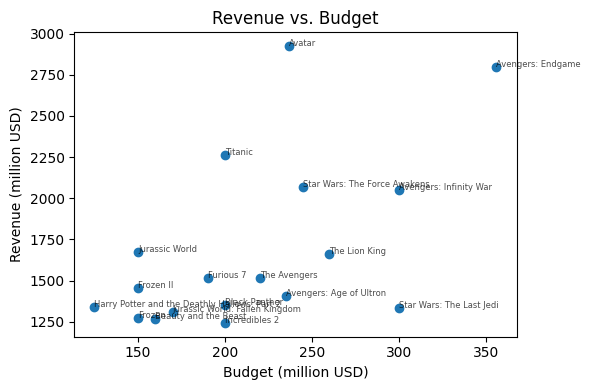

WindowsPath('C:/Users/User/OneDrive/Documents/AmaliTech/tmdb-movies-analysis-spark/outputs/revenue_vs_budget.png')

In [18]:
plot_revenue_vs_budget(df.toPandas())

**Insight:** There's a loose positive relationship between budget and revenue, but it's far from strict – points are labeled directly on the chart, so specific outliers can be identified visually rather than by cross-referencing separately.

### ROI Distribution by Genre

2026-08-09 12:00:59,235 [INFO] visualization.visualize: Saved chart to C:\Users\User\OneDrive\Documents\AmaliTech\tmdb-movies-analysis-spark\outputs\roi_by_genre.png


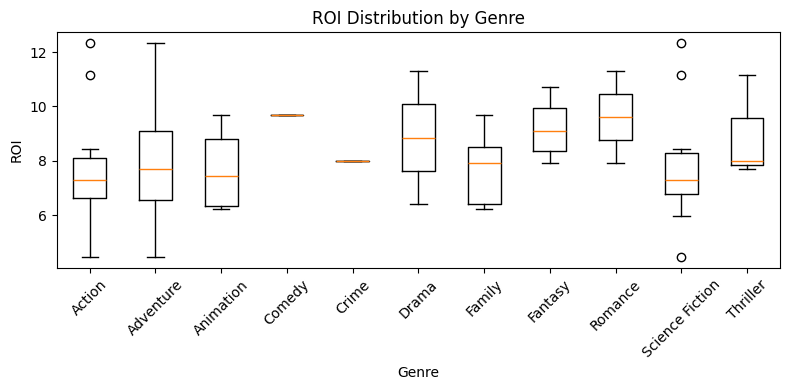

WindowsPath('C:/Users/User/OneDrive/Documents/AmaliTech/tmdb-movies-analysis-spark/outputs/roi_by_genre.png')

In [19]:
plot_roi_by_genre(df.toPandas())

**Insight:** ROI varies noticeably by genre. Genres represented by only 1-2 movies in this dataset show almost no spread – a sample-size artifact, not a real pattern.

### Popularity vs. Rating

2026-08-09 12:01:02,325 [INFO] visualization.visualize: Saved chart to C:\Users\User\OneDrive\Documents\AmaliTech\tmdb-movies-analysis-spark\outputs\popularity_vs_rating.png


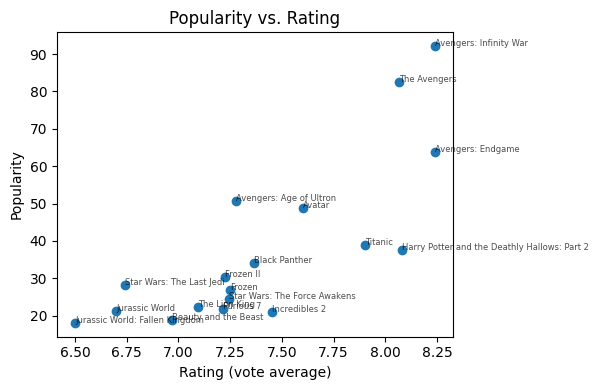

WindowsPath('C:/Users/User/OneDrive/Documents/AmaliTech/tmdb-movies-analysis-spark/outputs/popularity_vs_rating.png')

In [20]:
plot_popularity_vs_rating(df.toPandas())

**Insight:** Popularity and rating show a loose positive relationship but aren't strictly correlated – labeled points make it possible to identify exactly which movies diverge from the trend.

### Yearly Trends in Box Office Performance

2026-08-09 12:01:05,799 [INFO] visualization.visualize: Saved chart to C:\Users\User\OneDrive\Documents\AmaliTech\tmdb-movies-analysis-spark\outputs\yearly_trends.png


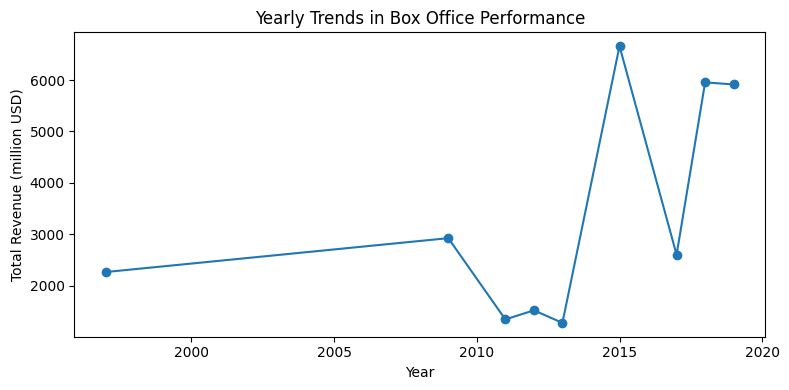

WindowsPath('C:/Users/User/OneDrive/Documents/AmaliTech/tmdb-movies-analysis-spark/outputs/yearly_trends.png')

In [21]:
plot_yearly_trends(df.toPandas())

**Insight:** Revenue spikes in later years reflect this dataset's concentration of major franchise releases. Gaps between distant years (e.g. 1997 to 2009) don't represent a real gradual trend – just the nearest two data points in a small, non-continuous dataset.

### Comparison of Franchise vs. Standalone Success

2026-08-09 12:01:09,061 [INFO] visualization.visualize: Saved chart to C:\Users\User\OneDrive\Documents\AmaliTech\tmdb-movies-analysis-spark\outputs\franchise_vs_standalone.png


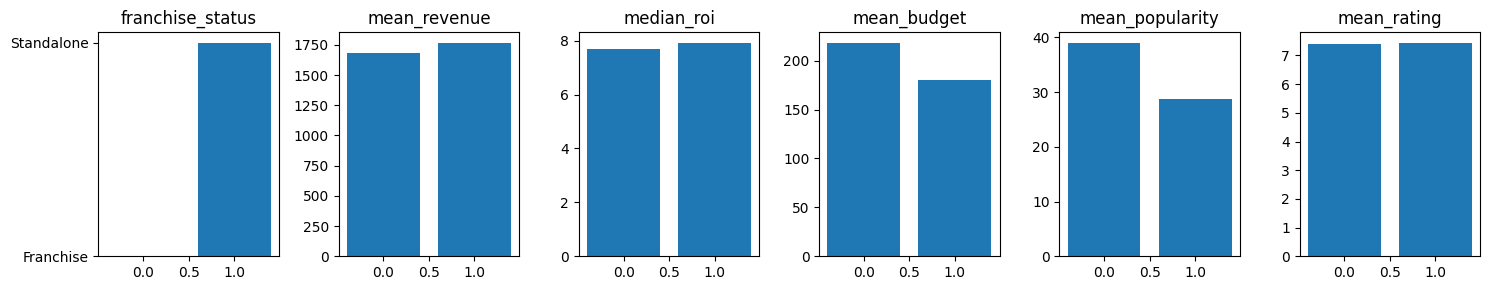

WindowsPath('C:/Users/User/OneDrive/Documents/AmaliTech/tmdb-movies-analysis-spark/outputs/franchise_vs_standalone.png')

In [22]:
plot_franchise_vs_standalone(comparison.toPandas())

**Insight:** Standalone movies outperform franchise movies on 4 of 5 metrics in this dataset – consistent with the small-sample caveat noted earlier in the Franchise vs. Standalone comparison table.